# Apply the Fama-French and Other Fundamental Models

* reproduce fama-french work
* review model
* review updates to the model
* run sectors
* run top-10 of each sector

In [1]:
%load_ext autoreload
%autoreload 2
%cd ..

/workspaces/API-macroecon-wrappy


In [2]:
import sys
sys.path.append('/workspaces/API-macroecon-wrappy')

In [3]:
from macroecon_wrappy import Auth

import pandas as pd
import yfinance as yf
import alpha_vantage as av

from pathlib import Path


secrets_path = Path('/workspaces/API-macroecon-wrappy/SECRETS.yaml')
cache_path = Path('/workspaces/API-macroecon-wrappy/tests/tmp/')
auth = Auth(secrets_path, cache_path)
auth.load_secrets()

True

In [11]:
#project
from macroecon_wrappy import (
    Auth,
    Metric,
    Measure,
    Epoch,
    plots
)
from macroecon_wrappy.adapters import (
    YahooFin
)

#external
import yfinance as yf

#system
from pathlib import Path

## The Standard Approach to Market Comparison Using Fama-French

### The alpha and beta coefficients

Alpha in finance is a measure of an investment's performance compared to a benchmark index (like the S&P 500). Often referred to as "excess return" or "beating the market," it represents the value a portfolio manager or strategy adds (or subtracts) beyond what would be expected given the risk taken.

* Alpha (α): The portion of the return that is specifically due to active management or skill.
  - Positive Alpha (α > 0): The investment outperformed the benchmark. For example, an alpha of +2% means the investment beat the market by 2%.
  - Negative Alpha (α < 0): The investment underperformed the market.
* Beta (β): Measures the investment's volatility or systematic risk in relation to the overall market.

If you invest in an index fund, your returns simply match the market, yielding an alpha of zero. If you actively pick stocks or use a specialized trading strategy, investors hope to generate a positive alpha.  For instance, if a mutual fund returns 12% in a year while its benchmark index returns 10%, the fund has an alpha. However, finance professionals adjust this number for risk using metrics like the Capital Asset Pricing Model (CAPM). If an investment takes on higher volatility than the market, its returns need to be correspondingly higher just to break even.

To understand how alpha and beta two work together:

* Beta is what you get just for showing up and investing in the market (e.g., riding the general upward trajectory of the stock market).
* Alpha is the reward for skill, timing, and security selection. It is the extra return generated on top of what Beta dictates.

Key considerations in finance:

* Seeking Alpha: Hedge funds, mutual fund managers, and quantitative traders actively hunt for alpha. Historically, opinions in investing forums such as Reddit Investing are mixed. There is ongoing debate over whether genuine "alpha" is getting harder to find due to the rise of passive index funds.
* Fees: Because active managers charge higher management fees, an investment must generate a positive alpha that is higher than its fees to actually benefit the investor.

### Breakthrough research

Alpha originates from the landmark 1968 academic paper titled "The Performance of Mutual Funds in the Period 1945–1964".  Some key historical facts include.  The paper was written by American economist Michael C. Jensen.  Jensen sought an absolute metric to evaluate whether mutual fund managers possessed genuine forecasting ability or were simply taking on higher risk.

Prior to this paper, the financial world relied primarily on relative ranking systems to judge investment managers. Jensen integrated the newly developed Capital Asset Pricing Model (CAPM) to isolate the baseline return an investor should expect based on the market's risk profile.

By inserting a constant into the regression equation — the mathematical Greek letter α (alpha) — he successfully separated general market exposure (Beta) from the specific value added or lost by the manager. The metric remains widely known today as Jensen's Alpha.

### CAPM and Jensen's alpha

Michael Jensen added an intercept term, $(\alpha _{i})$, to the standard Capital Asset Pricing Model (CAPM) equation to measure an investment's excess return. By converting the theoretical CAPM model into an empirical regression model, this constant isolated the returns generated by managerial skill from those generated by general market risk.

The original _Capital Asset Pricing Model (CAPM)_ states that the expected return of an asset depends strictly on its systematic risk ($\beta $). The theoretical formula is:

$$
E(R_{i})=R_{f}+\beta _{i}(E(R_{m})-R_{f})
$$

Where:

* $E(R_i)$ is the expected return of the specific asset or portfolio $i$.
* $R_{f}$ is the risk-free rate of return (like government bonds).
* $\beta _{i}$ is the beta coefficient of the asset, measuring its sensitivity to the market.
* $E(R_m)$ is the expected return of the overall market portfolio.
* $(E(R_m) - R_f)$ is the market risk premium.

To test this theory against real historical data from mutual funds, Jensen needed to transform the theoretical relationship into an empirical _linear regression equation_. He subtracted the risk-free rate ($R_{f}$) from both sides to focus purely on risk premiums:

$$
R_{it}-R_{ft}=\beta _{i}(R_{mt}-R_{ft})
$$

Where $t$ represents specific historical time intervals.

He then inserted the constant alpha ($\alpha $).  In standard linear regression, a line is defined by $y = \alpha + \beta x + \epsilon$. Jensen inserted the constant parameter $\alpha _{i}$ as the _y-intercept_ and added a random error term $\epsilon _{it}$:

$$
R_{it}-R_{ft}=\alpha _{i}+\beta _{i}(R_{mt}-R_{ft})+\epsilon _{it}
$$

Note:

* the constant ($\alpha _{i}$): This constant captures any return that the CAPM model cannot explain through market risk exposure.
* the intercept function: If CAPM held perfectly true and managers possessed no picking skill, the line would pass exactly through the origin, making $\alpha_i = 0$.
* the residual ($\epsilon _{it}$): This captures random market noise with an expected value of zero over time.

By running this linear regression on historical fund returns, Jensen could mathematically evaluate whether a manager added value.

* If $\alpha_i > 0$: The manager earned a positive risk-adjusted premium above market expectations.
* If $\alpha_i < 0$: The manager underperformed relative to the systematic risk they took on.

The following is Jensen's Alpha equation:

$$
R_{it}-R_{ft}=\alpha _{i}+\beta _{i}(R_{mt}-R_{ft})+\epsilon _{it}
$$

Michael Jensen successfully transformed the theoretical CAPM by inserting $\alpha _{i}$ as a regression constant to isolate and mathematically measure an investment manager's true stock-picking skill.

### Fama-French solidifies as standard

The evolution from Jensen's CAPM-based alpha to the Fama-French Three-Factor Model occurred because researchers found that a single market beta could not explain why certain types of stocks consistently outperformed others. In 1992 and 1993, economists Eugene Fama and Kenneth French expanded the regression model by adding two new risk factors, changing how alpha is calculated and raising the bar for what qualifies as true managerial skill.

Fama and French identified anomalies in CAPM.  Under Jensen's CAPM framework, all returns are expected to come from a single factor: the market risk premium. However, historical data revealed two major anomalies where groups of stocks systematically beat the market without CAPM accounting for it:

* The Size Effect: Small-cap companies historically outperformed large-cap companies.
* The Value Effect: High book-to-market companies (value stocks) historically outperformed low book-to-market companies (growth stocks).

Because CAPM ignored these traits, an investment manager who simply bought small-cap value stocks would show an artificially high, positive "Jensen's Alpha," even though they were just riding a known structural market anomaly rather than using unique stock-picking skill.

They formulated the Three-Factor regression model to account for these effects.  To fix this, Fama and French expanded the linear regression equation. They kept the original market factor but added two new empirical factors to account for the size and value anomalies:

* SMB (Small Minus Big): Measures the historic excess returns of small-cap stocks over large-cap stocks.
* HML (High Minus Low): Measures the historic excess returns of value stocks (high book-to-market) over growth stocks (low book-to-market).

The resulting baseline Fama-French Three-Factor regression model is formulated as:

$$
R_{it}-R_{ft}=\alpha _{i}+\beta _{i1}(R_{mt}-R_{ft})+\beta _{i2}\text{SMB}_{t}+\beta _{i3}\text{HML}_{t}+\epsilon _{it}
$$

Where: 

* $R_{it} - R_{ft}$ is the excess return of the asset or portfolio.
* $\alpha _{i}$ is the new, multi-factor Alpha.
* $\beta_{i1}, \beta_{i2}, \beta_{i3}$ are the sensitivities (loadings) to the Market, Size, and Value factors respectively.
* $\epsilon _{it}$ is the residual error term.

But, to do this, they needed to redefine the definition of Alpha.  By adding SMB and HML to the equation, the definition of Alpha fundamentally changed.

* Under Jensen's CAPM: Alpha represents performance relative to the broad market index.
* Under Fama-French: Alpha represents performance relative to a diversified mix of assets with the exact same size and value characteristics.

If a manager builds a portfolio of small-cap value stocks, their $\beta _{i2}$ (SMB loading) and $\beta _{i3}$ (HML loading) will capture those returns. The Fama-French model strips away those structural tailwinds, exposing whether the manager generated any additional excess return $(\alpha _{i})$.

This is the initial evolution of the Fama-French Model:

$$
R_{it}-R_{ft}=\alpha _{i}+\beta _{i1}(R_{mt}-R_{ft})+\beta _{i2}\text{SMB}_{t}+\beta _{i3}\text{HML}_{t}+\epsilon _{it}
$$

The evolution to the Fama-French model shrunk the calculated alpha for many active managers by proving that their "excess returns" were actually a result of passive exposure to small-cap and value risk factors rather than genuine stock-picking skill.

### Continued model evolution

Additional models sprang from this work - most notably the Carhart Four-Factor Model and the Fama-French Five-Factor Model.  These differ primarily in how they define the structural risk premiums that drive stock returns, but the industry standard for comparing general investment results against the market remains the original Fama-French Three-Factor Model or basic CAPM.

While both models attempt to shrink unexplained alpha by accounting for market anomalies, they target fundamentally different behavioral and fundamental drivers.  The Carhart Four-Factor Model (1997) blends firm fundamentals with behavioral market psychology (price persistence).  The new factor is MOM (Momentum): Upward or downward price trends tend to persist for 3–12 months.  This drastically reduces alpha for trend-following strategies and systematic momentum funds.  It is best for evaluating active mutual fund managers and high-turnover trading strategies.

The Fama-French Five-Factor Model (2015) strips out price psychology to focus purely on corporate financial health and capital allocation.  It includes RMW (Robust Minus Weak): highly profitable firms outperform those with weak profits, and CMA (Conservative Minus Aggressive): companies that invest conservatively outperform aggressive spenders.  This drastically reduces alpha for quality-focused strategies and long-term value/income funds.  It is best for evaluating corporate cost of capital, accounting research, and long-term asset pricing.


### Preference based on field

Despite the academic superiority of the 4-factor and 5-factor models, they are rarely used by the general public or everyday institutional investors to judge basic market performance. Instead, the financial industry relies on hierarchical tiers:

* The Industry Standard: The S&P 500 / Direct Benchmark (Absolute Beta) - The absolute most popular approach in retail investing, wealth management, and quarterly performance reporting is simply comparing a portfolio’s absolute return against its relevant index (e.g., the S&P 500 or MSCI World). If the index returned 10% and the fund returned 11%, it is widely marketed as beating the market, ignoring risk adjustments entirely.
* The Institutional Baseline: The Fama-French Three-Factor Model - When institutional allocators and pension funds require a risk-adjusted multi-factor comparison, they overwhelmingly favor the Fama-French Three-Factor Model (Market + Size + Value).  It strikes the perfect balance between simplicity and explanatory power.It captures over 90% of a diversified portfolio's returns without needing the complex, high-turnover data rebalancing required by the Momentum (Carhart) or Profitability/Investment (FF5) factors.
* The Academic Consensus: The Carhart Four-Factor Model - If forced to pick between the Carhart 4-Factor and the Fama-French 5-Factor model specifically for evaluating active fund managers, academics and advanced hedge fund allocators generally prefer the Carhart Four-Factor Model.  This is because active mutual fund managers frequently trade into trending stocks (chasing momentum), either intentionally or due to retail cash inflows.  If a model fails to control for momentum (like the Fama-French 5-Factor model, which notoriously omits it), a manager's alpha will look artificially inflated simply because they bought stocks that were already going up.

### Reproduce using code

We will compare a target portfolio (from the provided dataset) against the market returns.  The dataset is the 'Fama-French 25 Portfolios Formed on Size and Book-to-Market'.

This is the gold standard for testing asset pricing models.  It is a matrix of 25 value-weighted portfolios created by intersecting 5 size groups (Market Equity) and 5 value groups (Book-to-Market Equity).  Fama and French originally used these exact portfolios to prove their model. Testing the model against these highlights how well size and value explain return variations.  Download it directly through Python’s pandas_datareader using the name 25_Portfolios_5x5.

We will select an individual target portfolio out of the 25 matrix intersections.  The `Small-cap / High Value` stocks denoted by ('SMALL HiBM') will work.

Three step process:

* Access the Data: Go to the official Kenneth R. French Data Library.  
  - Daily Returns:	 	July 1, 1926 - May 31, 2026
* Choose Your Model: Select the 3-Factor (Market, Size, Value), 5-Factor (adds Profitability and Investment), or Momentum models.
* Download: You can download these factor returns in CSV or text formats to use in your financial modeling.
* Regression: The regression equation for the 3-Factor model is:

$$
R_i - R_f = \alpha + \beta_1(R_m - R_f) + \beta_2(\text{SMB}) + \beta_3(\text{HML}) + \epsilon
$$

Where:
* $R_{i}$ = Return of the portfolio or stock
* $R_{f}$ = Risk-free rate
* α (Alpha) = Excess risk-adjusted performance
* $R_m - R_f$ = Market risk premium
* β₁, β₂, β₃ = Factor sensitivities

Interpreted as:

* $R_{it} - R_{ft}$ is the excess return of the asset or portfolio.
* $\alpha _{i}$ is the new, multi-factor Alpha.
* $\beta_{i1}, \beta_{i2}, \beta_{i3}$ are the sensitivities (loadings) to the Market, Size, and Value factors respectively.
* $\epsilon _{it}$ is the residual error term.


References:

* [Kenneth R. French Data Library](https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html)
* [details](https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/Data_Library/f-f_factors.html)
* [replicate and check factors](https://www.tidy-finance.org/chapters/replicating-fama-and-french-factors.html#portfolio-sorts)


Manual approach.

In [ ]:
import pandas as pd
import pandas_datareader.data as web
import requests


import io
import zipfile

In [ ]:

#3-factor model
url_3_factor_daily = 'https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_daily_CSV.zip'
response = requests.get(
    url=url_3_factor_daily
    )

In [ ]:
#extract contents directly to a dictionary variable
extracted_contents = {}

with zipfile.ZipFile(io.BytesIO(response.content)) as zfile:
    for filename in zfile.namelist():
        # Skips directories to only extract files
        if not filename.endswith("/"):
            # Saves raw binary data to the variable
            extracted_contents[filename] = zfile.read(filename)

# Example: Read a text file from the variable
# print(extracted_contents['example.txt'].decode('utf-8'))

In [110]:
daily = extracted_contents['F-F_Research_Data_Factors_daily.csv']
df = pd.read_csv(
    io.BytesIO(daily), 
    skiprows=3
)
df.rename(columns={df.columns[0]: 'date'}, inplace=True)
df = df.drop(df.index[-1])
df['date'] = pd.to_datetime(df['date'])
df.set_index(df['date'])
df.head()

,date,Mkt-RF,SMB,HML,RF
0,1926-07-01,0.09,-0.25,-0.27,0.01
1,1926-07-02,0.45,-0.33,-0.06,0.01
2,1926-07-06,0.17,0.30,-0.39,0.01
3,1926-07-07,0.09,-0.58,0.02,0.01
4,1926-07-08,0.22,-0.38,0.19,0.01


In [ ]:
#comparison portfolio: Fama-French 25 Portfolios Formed on Size and Book-to-Market
# 1. Fetch the raw dataset dictionary starting from Jan 1927
# The official identifier string is exactly '25_Portfolios_5x5'
data_dict = web.DataReader('25_Portfolios_5x5', 'famafrench', start='1927-01-01')

# 2. Inspect the dictionary keys to find your target table
print("Available tables:", data_dict.keys())
print("\nDataset Description:\n", data_dict['DESCR'])

# 3. Extract your specific target portfolio table
# Key 0 is traditionally the Value-Weighted Monthly Returns
# Key 1 is traditionally the Equal-Weighted Monthly Returns
df_value_weighted = data_dict[0]

# 4. Convert percentages (e.g., 2.5) to decimals (e.g., 0.025)
portfolio_returns = df_value_weighted / 100
portfolio_returns.index = portfolio_returns.index.to_timestamp()    #ensure day is available
portfolio_returns.head()

Available tables: dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 'DESCR'])

Dataset Description:
 25 Portfolios 5x5
-----------------

This file was created using the 202605 CRSP database. It contains value- and equal-weighted returns for portfolios formed on ME and BEME. The portfolios are constructed at the end of June. BEME is book value at the last fiscal year end of the prior calendar year divided by ME at the end of December of the prior year. Annual returns are from January to December. Missing data are indicated by -99.99 or -999. The break points include utilities and include financials The portfolios include utilities and include financials. Copyright 2026 Eugene F. Fama and Kenneth R. French

  0 : Average Value Weighted Returns -- Monthly (1193 rows x 25 cols)
  1 : Average Equal Weighted Returns -- Monthly (1193 rows x 25 cols)
  2 : Average Value Weighted Returns -- Annual (99 rows x 25 cols)
  3 : Average Equal Weighted Returns -- Annual (99 rows x 25 cols)
  4 : Number of Fir

,SMALL LoBM,ME1 BM2,ME1 BM3,ME1 BM4,SMALL HiBM,ME2 BM1,ME2 BM2,ME2 BM3,ME2 BM4,ME2 BM5,...,ME4 BM1,ME4 BM2,ME4 BM3,ME4 BM4,ME4 BM5,BIG LoBM,ME5 BM2,ME5 BM3,ME5 BM4,BIG HiBM
Date,,,,,,,,,,,,,,,,,,,,,
1927-01-01,0.010954,-0.081352,-0.048280,0.030498,0.020210,0.030069,-0.042859,0.002068,-0.000539,0.110570,...,0.023758,0.014755,-0.005061,0.002309,0.073063,-0.007786,0.003288,-0.004352,0.005531,0.042141
1927-02-01,0.028672,-0.004922,0.085078,0.052580,0.099280,0.015090,0.102367,0.078700,0.036064,0.075867,...,0.052958,0.042687,0.023470,0.067817,0.114693,0.034579,0.051109,0.034245,0.051397,0.062731
1927-03-01,0.058224,-0.000730,-0.058769,-0.039186,-0.035776,-0.024637,-0.028410,-0.020166,-0.007001,-0.006648,...,-0.022015,0.001654,-0.013741,-0.013765,0.039110,0.005893,0.020005,-0.001196,0.004786,-0.038449
1927-04-01,0.078274,0.047880,0.043995,0.033905,0.064235,-0.029654,-0.041614,-0.003033,-0.004134,0.045992,...,-0.002726,0.018583,-0.011458,0.000691,0.057530,0.026945,0.008938,-0.003006,-0.004253,-0.035345
1927-05-01,0.100338,0.072563,0.025787,0.146799,0.109637,0.073147,0.021944,0.054370,0.090003,0.134530,...,0.048348,0.061917,0.036611,0.071863,0.077199,0.056953,0.046865,0.055468,0.054254,0.047762


This is the automated approach.

In [118]:
import pandas as pd
import statsmodels.api as sm
import pandas_datareader.data as web

start_date = '1927-01-01'

# 1. Fetch daily 3-factors (Market-RF, SMB, HML, RF)
factors_dict = web.DataReader('F-F_Research_Data_Factors_daily', 'famafrench', start=start_date)
daily_factors = factors_dict[0] / 100  # Convert percentages to decimals

# 2. Fetch daily companion portfolios (25 Size/Book-to-Market)
portfolios_dict = web.DataReader('25_Portfolios_5x5_Daily', 'famafrench', start=start_date)
daily_portfolios = portfolios_dict[0] / 100  # Extract Value-Weighted daily table

In [120]:
# Convert both indices to strict DatetimeIndex timestamps
daily_factors.index = daily_factors.index.to_timestamp()
daily_portfolios.index = daily_portfolios.index.to_timestamp()

# Select an individual target portfolio out of the 25 matrix intersections
# Example: Small-cap / High Value stocks ('SMALL HiBM')
target_portfolio = daily_portfolios[['SMALL HiBM']]


In [121]:
# Merge factors and portfolio data based on overlapping dates
merged_data = pd.merge(target_portfolio, daily_factors, left_index=True, right_index=True, how='inner')

# Calculate the target asset's daily Excess Return (R_it - R_ft)
merged_data['Portfolio_Excess'] = merged_data['SMALL HiBM'] - merged_data['RF']

print(merged_data[['Portfolio_Excess', 'Mkt-RF', 'SMB', 'HML']].head())

            Portfolio_Excess  Mkt-RF     SMB     HML
Date                                                
1927-01-03            0.0119 -0.0079  0.0019  0.0009
1927-01-04            0.0012  0.0030  0.0014 -0.0066
1927-01-05            0.0149  0.0014  0.0046 -0.0036
1927-01-06            0.0123 -0.0018 -0.0005  0.0015
1927-01-07           -0.0001  0.0030 -0.0023  0.0041


In [122]:
# Define Y (Dependent variable) and X (Independent variables)
Y = merged_data['Portfolio_Excess']
X = merged_data[['Mkt-RF', 'SMB', 'HML']]

# Add Alpha intercept (c) to the regression formula
X = sm.add_constant(X)

# Fit Ordinary Least Squares (OLS) model
daily_model = sm.OLS(Y, X).fit()

# View complete statistical results
print(daily_model.summary())

                            OLS Regression Results                            
Dep. Variable:       Portfolio_Excess   R-squared:                       0.820
Model:                            OLS   Adj. R-squared:                  0.820
Method:                 Least Squares   F-statistic:                 3.955e+04
Date:                Thu, 16 Jul 2026   Prob (F-statistic):               0.00
Time:                        02:24:57   Log-Likelihood:                 97853.
No. Observations:               26103   AIC:                        -1.957e+05
Df Residuals:                   26099   BIC:                        -1.957e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0001   3.53e-05      3.110      0.0

### Interpretation of Results

__Model Fit (The Top Block)__

* R-squared & Adj. R-squared (0.820): Your model explains 82.0% of the variance in your portfolio's daily excess returns. In daily financial data, an R-squared this high is an excellent fit.

__Factor Interpretations (The Coefficients Block)__

Every single predictor in your model has a P-value of 0.000 (or 0.002 for alpha). This means every factor is highly statistically significant (well below the standard 0.05 threshold).

* const / Alpha (0.0001, p=0.002): This is your daily abnormal return (Alpha). A coefficient of 0.0001 means the portfolio outperforms the model by 0.01% per day (roughly 2.5% to 3% annualized) after adjusting for risk. Because the p-value is 0.002, this outperformance is statistically real, not noise.
* Mkt-RF / Market Beta (0.9124, p=0.000): For every 1.0% move in the broader market's excess return, your portfolio moves by 0.91%. A beta slightly below 1.0 means this portfolio is slightly less volatile than the overall market.
* SMB / Size Loading (1.0849, p=0.000): A positive SMB coefficient means your portfolio behaves like small-cap stocks. A loading of 1.08 is very strong, heavily tilting your portfolio toward smaller companies.
* HML / Value Loading (0.6689, p=0.000): A positive HML coefficient means your portfolio behaves like value stocks (companies with high book-to-market ratios). A loading of 0.67 indicates a clear, undeniable value tilt.

__Diagnostics & Underlying Assumptions (The Bottom Block)__

While the model has high explanatory power, the diagnostic tests show that standard daily market data violates classical linear regression assumptions.

* Durbin-Watson (2.362): A value of 2.0 indicates zero autocorrelation. Your value of 2.36 suggests a slight negative serial correlation between consecutive days (meaning a positive return day is slightly more likely to be followed by a negative return day).
* Jarque-Bera & Omnibus (p = 0.000): These tests assess the normality of your regression residuals. A p-value of 0.00 means your residuals are not normally distributed.
* Skew (1.555) & Kurtosis (61.703): This explains the non-normality. A normal distribution has a Kurtosis of 3.0. Your Kurtosis of 61.7 shows massive "fat tails" (leptokurtosis). Your portfolio experiences frequent, extreme daily outlier events (market crashes or massive spikes) that a standard linear model cannot fully anticipate.

__Conclusion__

The dataset represents a Small-Cap Value portfolio that slightly under-participates in broad market swings (Beta = 0.91) but generates a consistent, tiny slice of daily outperformance (Alpha = 0.01% daily) that cannot be explained by size, value, or market movements alone.

## Review Sectors

`yfinance` has built-in Sector and Industry objects, but they do not automatically provide a pre-made static list of tickers like ['XLK', 'XLV']. Instead, yfinance fetches live sector data directly from Yahoo Finance on demand.You can use the built-in yf.Sector class to dynamically fetch details, including the top ETFs and top companies belonging to that specific sector.

While the built-in `yf.Sector` object can pull the top ETFs for a sector, those lists are subject to change based on market cap or Yahoo Finance's internal ranking layout. For historical charting or sector-rotation tracking over time, hardcoding the specific standard SPDR Sector ETFs (like XLK for Tech, XLF for Financials) ensures your data pull remains perfectly consistent, clean, and fast.

In [10]:

#the 11 major Sector ETFs
sectors = {
    'XLK': 'Technology',
    'XLV': 'Health Care',
    'XLF': 'Financials',
    'XLY': 'Consumer Discretionary',
    'XLP': 'Consumer Staples',
    'XLI': 'Industrials',
    'XLB': 'Materials',
    'XLE': 'Energy',
    'XLU': 'Utilities',
    'XLRE': 'Real Estate',
    'XLC': 'Communication Services'
}

#historical 'Adj Close' prices for the last year
tickers_list = list(sectors.keys())

In [6]:
data = yf.download(tickers_list, period='1y')#['Adj Close']
data.head(3)

[*********************100%***********************]  11 of 11 completed


Price           Close                                                \
Ticker            XLB         XLC        XLE        XLF         XLI   
Date                                                                  
2025-07-15  43.772621  104.673592  42.127331  50.860710  147.972961   
2025-07-16  43.890472  104.989616  41.763664  51.215206  148.496231   
2025-07-17  44.199837  105.355034  42.020657  51.707565  149.868546   

Price                                                                ...  \
Ticker             XLK        XLP       XLRE        XLU         XLV  ...   
Date                                                                 ...   
2025-07-15  128.281784  77.909225  39.933193  39.882801  130.323776  ...   
2025-07-16  128.679703  78.181664  40.368195  39.902260  131.945450  ...   
2025-07-17  129.848541  78.921150  40.329525  40.067650  130.441696  ...   

Price        Volume                                                    \
Ticker          XLC       XLE       XLF       XLI       XLK       XLP   
Date                                                                    
2025-07-15  5813500  33859000  47704600  10278700  15657000  17681600   
2025-07-16  6812600  35501600  46726500   9998300  17782600  15633600   
2025-07-17  4640100  36085600  48213900  13374200  11955000  17079000   

Price                                              
Ticker         XLRE       XLU       XLV       XLY  
Date                                               
2025-07-15  6427500  26253000  17095600  10133200  
2025-07-16  8487900  22625000  14142100  13982600  
2025-07-17  7848700  19757000  15740900   7742400  

[3 rows x 55 columns]

In [ ]:
returns = []
for tkr, item in data['Close'].items():
    metric1 = Metric(item)
    metric1.set_metadata(title=tkr)
    cumulative_returns = metric1.returns(type='cumulative')
    rtn = pd.DataFrame(cumulative_returns)
    #calculate cumulative returns over time (normalized to start at 0%)
    #formulated as: (Price_t / Price_initial) - 1
    cumulative_returns = (rtn / rtn.iloc[1]) - 1
    cumulative_returns.rename(columns={0: 'cum_rtn'}, inplace=True)
    cumulative_returns['tkr'] = tkr
    metric2 = Metric(cumulative_returns['cum_rtn'])
    returns.append(metric2)

measure = Measure(returns)

In [83]:
long = measure.to_long()
long.shape

(2761, 2)

In [85]:
cols = {f'col-{idx}': tkr for idx,tkr in enumerate(sectors.keys())}
#long.rename(columns=cols, inplace=True)
long['grp'] = long['grp'].astype('category')
long['grp'] = long['grp'].cat.rename_categories(cols)
long.rename(columns={'grp': 'tkr', 'value': 'return'}, inplace=True)
long.reset_index(inplace=True)

In [87]:
long.head(3)

,timestamp,tkr,return
0,2026-07-14,XLK,0.153781
1,2026-07-13,XLK,0.152414
2,2026-07-10,XLK,0.159477


/workspaces/API-macroecon-wrappy/.venv/lib/python3.12/site-packages/plotnine/geoms/geom_path.py:100: PlotnineWarning: geom_path: Removed 1 rows containing missing values.


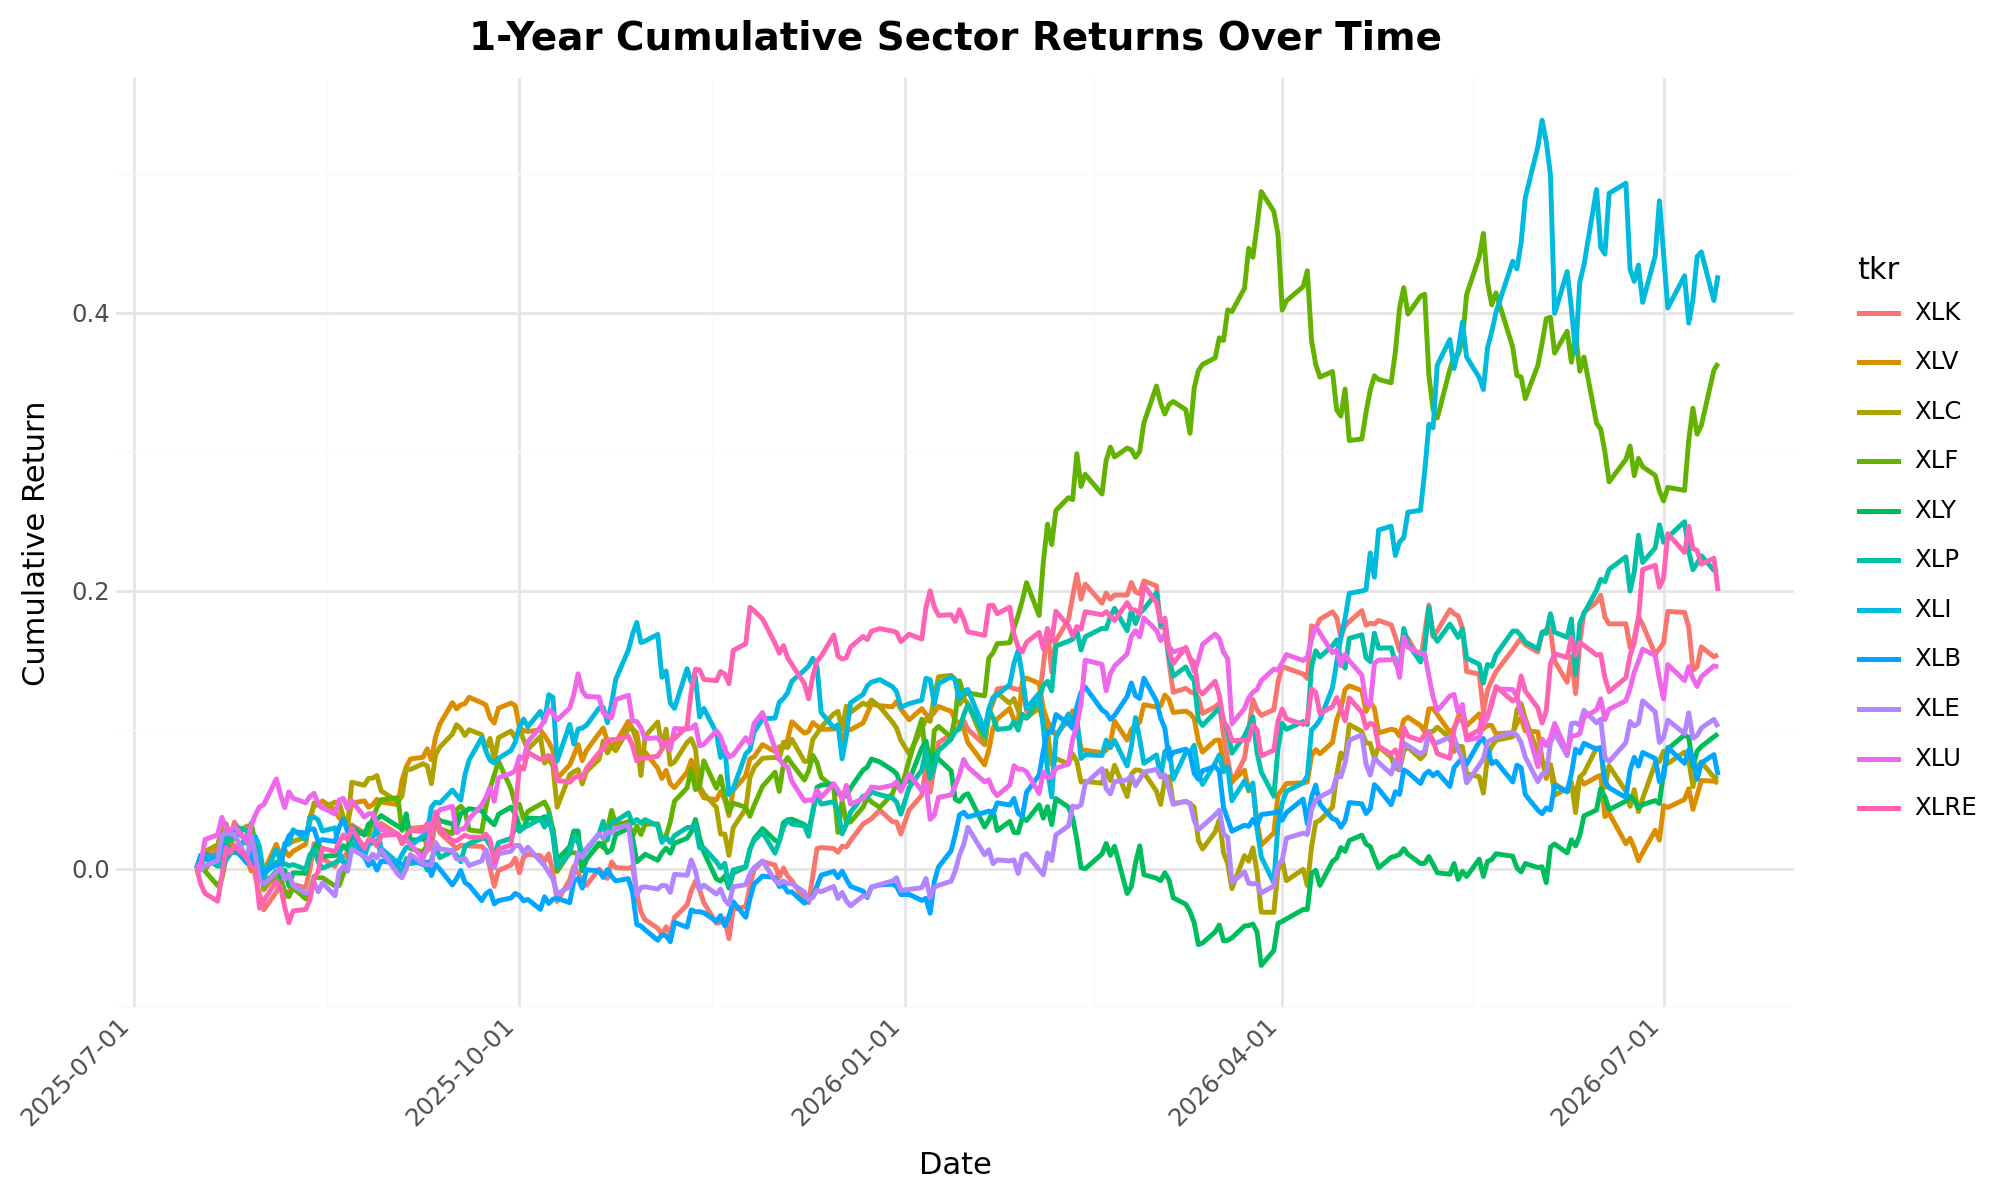

In [88]:
from plotnine import ggplot, aes, geom_line, labs, theme_minimal, theme, element_text

plot = (
    ggplot(long, aes(x='timestamp', y='return', color='tkr'))
    + geom_line(size=1)
    + labs(
        title="1-Year Cumulative Sector Returns Over Time",
        x="Date",
        y="Cumulative Return",
    )
    + theme_minimal()
    + theme(
        figure_size=(10, 6),
        axis_text_x=element_text(rotation=45, hjust=1),
        plot_title=element_text(size=14, weight='bold')
    )
)

plot

## Top Firms in Each Sector

In [ ]:
import yfinance as yf
import pandas as pd
import time

# 1. Define standard built-in Yahoo Finance sector keys
sector_keys = [
    "technology", 
    "financial-services", 
    "healthcare", 
    "consumer-cyclical", 
    "industrials", 
    "energy"
]

# 2. Container to collect dataframes
all_sectors_data = []

print("Fetching data from Yahoo Finance...\n")

for key in sector_keys:
    try:
        # Initialize yf.Sector for the specific key
        sector_obj = yf.Sector(key)
        
        # Extract the live top companies table (returns a pandas DataFrame)
        top_companies_df = sector_obj.top_companies
        
        if top_companies_df is not None and not top_companies_df.empty:
            # Filter down to the top 5 companies 
            top_5 = top_companies_df.head(5).copy()
            
            # Inject meta columns so we know which sector they belong to
            top_5['Sector Key'] = key
            top_5['Sector Name'] = sector_obj.name
            
            # Save to list
            all_sectors_data.append(top_5)
            print(f"✅ Successfully retrieved top 5 for: {sector_obj.name}")
        else:
            print(f"⚠️ No company data available for sector key: '{key}'")
            
    except Exception as e:
        print(f"❌ Error fetching sector key '{key}': {e}")
        
    # Polite pause between API calls to prevent rate limits
    time.sleep(1)

# 3. Combine everything into a single structured master DataFrame
if all_sectors_data:
    master_df = pd.concat(all_sectors_data, ignore_index=True)
    
    # Reorder columns to place Sector information cleanly at the front
    cols = ['Sector Name', 'Sector Key'] + [c for c in master_df.columns if c not in ['Sector Name', 'Sector Key']]
    master_df = master_df[cols]
    
    # 4. Display the results
    print("\n" + "="*50)
    print("      MASTER TOP 5 COMPANIES PER SECTOR       ")
    print("="*50)
    print(master_df.to_string(index=False))
else:
    print("\nNo data was successfully retrieved.")
